# 02 - Preprocessing & Augmentation

Demonstrates the resize/cast preprocessing pipeline and the augmentation layers
defined in `src/data/`, and visually confirms both behave as intended before
they are used in model training.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # silence TF/CUDA info-level logs

import sys
from pathlib import Path

import tensorflow as tf

sys.path.insert(0, str(Path.cwd().parent))

from src.config import IMG_SIZE
from src.data.augmentation import build_augmentation_layer
from src.data.dataset import build_pipeline, load_raw_splits
from src.utils.visualization import plot_augmentation_examples, savefig

## Preprocessing pipeline

`build_pipeline()` resizes every image to `224x224` and casts to `float32`
(no [0,1] rescaling — see `docs/architecture.md` for why). Confirm the output
shape and dtype match what the models expect.

In [2]:
train_raw, val_raw, test_raw, info = load_raw_splits()

# Inspect one raw image before preprocessing
raw_image, raw_label = next(iter(train_raw))
print(f"Raw image shape:  {raw_image.shape}  dtype: {raw_image.dtype}")

pipeline = build_pipeline(train_raw, training=False, batch_size=4)
batch_images, batch_labels = next(iter(pipeline))
print(f"Batch shape:       {batch_images.shape}  dtype: {batch_images.dtype}")
print(f"Pixel value range: [{tf.reduce_min(batch_images):.1f}, {tf.reduce_max(batch_images):.1f}]")

Raw image shape:  (500, 667, 3)  dtype: <dtype: 'uint8'>
Batch shape:       (4, 224, 224, 3)  dtype: <dtype: 'float32'>
Pixel value range: [0.0, 255.0]


## Data augmentation

The augmentation layer (`RandomFlip`, `RandomRotation`, `RandomZoom`,
`RandomContrast`) is applied here directly with `training=True` to visualize its
effect. In the actual models it lives *inside* the model graph, so it is active
only during `model.fit()` and automatically skipped during evaluation/inference.

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/02_augmentation_examples.png')

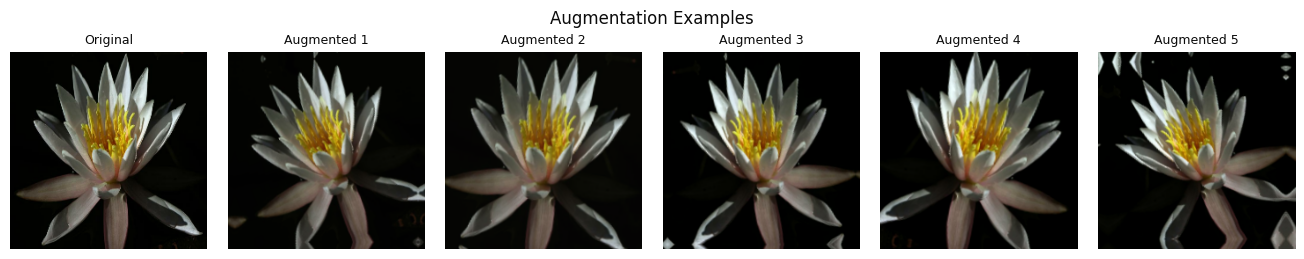

In [3]:
augmentation = build_augmentation_layer()

example_image = tf.image.resize(raw_image, (IMG_SIZE, IMG_SIZE))
example_batch = tf.expand_dims(example_image, 0)

variants = [augmentation(example_batch, training=True)[0].numpy() for _ in range(5)]

fig = plot_augmentation_examples(example_image.numpy(), variants, title="Augmentation Examples")
savefig(fig, "02_augmentation_examples.png")

In [4]:
import numpy as np

inference_output = augmentation(example_batch, training=False)[0].numpy()
identical = np.allclose(inference_output, example_image.numpy())
print(f"Augmentation is a no-op at inference (training=False): {identical}")

Augmentation is a no-op at inference (training=False): True


## Key takeaways

- Preprocessing produces a consistent `224x224x3` `float32` batch regardless of
  each image's original size, in the `[0, 255]` range expected by EfficientNetB0.
- Augmentation is mild by design (small rotation/zoom/contrast changes, horizontal
  flip) to avoid distorting the color and shape cues that distinguish visually
  similar flower species.
- Because augmentation is implemented as model layers rather than a dataset
  transform, validation/test evaluation is guaranteed to see unaugmented images
  with no extra code to keep in sync.